In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet18_Weights

import pandas as pd
import numpy as np
import os
import random
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

# Paths
train_path = "../data/processed/tabular/train_data.csv"
test_path = "../data/processed/tabular/test_data.csv"

Using Device: cpu


In [3]:
# Load training data once
train_df = pd.read_csv(train_path)

# Target scaler (FIT ON TRAIN ONLY)
target_scaler = MinMaxScaler()
target_scaler.fit(train_df[['energy_consumption_kwh']])

# Tabular feature scaler
tabular_cols = [
    'median_income',
    'population_density',
    'avg_building_age',
    'market_volatility'
]

tabular_scaler = StandardScaler()
tabular_scaler.fit(train_df[tabular_cols])

print("Scalers fitted on training data only (No Data Leakage).")

Scalers fitted on training data only (No Data Leakage).


In [4]:
class SmartCityDataset(Dataset):
    def __init__(self, csv_file, tab_scaler=None, target_scaler=None):
        self.data = pd.read_csv(csv_file).reset_index(drop=True)
        self.tab_scaler = tab_scaler
        self.target_scaler = target_scaler

        self.tab_cols = tabular_cols
        self.target_col = 'energy_consumption_kwh'

        # ImageNet normalization (Standard for ResNet)
        self.img_mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
        self.img_std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # -------- Image --------
        img_path = row['file_path']
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Missing image file: {img_path}")

        image = np.load(img_path).astype(np.float32)

        # Fix Channel Issue (Ensure 3 channels)
        if image.shape[2] > 3:
            image = image[:, :, :3]
            
        # Transform to PyTorch format (Channels, Height, Width)
        image = np.transpose(image, (2, 0, 1))
        
        # Apply ImageNet Standardization
        image = (image - self.img_mean) / self.img_std

        # -------- Tabular --------
        tabular = row[self.tab_cols].values.astype(np.float32)
        if self.tab_scaler:
            tabular = self.tab_scaler.transform([tabular])[0]

        # -------- Target --------
        target = row[self.target_col]
        if self.target_scaler:
            target = self.target_scaler.transform([[target]])[0][0]

        return {
            "image": torch.tensor(image, dtype=torch.float32),
            "tabular": torch.tensor(tabular, dtype=torch.float32),
            "target": torch.tensor(target, dtype=torch.float32)
        }

In [5]:
train_dataset = SmartCityDataset(
    train_path,
    tab_scaler=tabular_scaler,
    target_scaler=target_scaler
)

test_dataset = SmartCityDataset(
    test_path,
    tab_scaler=tabular_scaler,
    target_scaler=target_scaler
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0, # Set to 0 for Windows compatibility safety
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("DataLoaders initialized.")

DataLoaders initialized.


In [6]:
class SustainabilityModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Image branch (pretrained ResNet18)
        self.cnn = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        self.cnn.fc = nn.Identity()  # Output: 512 features

        # Freeze CNN weights (Faster Training!)
        for param in self.cnn.parameters():
            param.requires_grad = False

        # Tabular branch
        self.tabular_net = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32) # Adds stability
        )

        # Fusion head
        self.regressor = nn.Sequential(
            nn.Linear(512 + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, image, tabular):
        img_feat = self.cnn(image)
        tab_feat = self.tabular_net(tabular)
        x = torch.cat([img_feat, tab_feat], dim=1)
        return self.regressor(x).squeeze(1)

model = SustainabilityModel().to(device)
print("Model initialized (CNN Frozen).")

Model initialized (CNN Frozen).


Starting training...


c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler

Epoch [10/50] - Loss: 0.021995


c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler

Epoch [20/50] - Loss: 0.019357


...

Epoch [30/50] - Loss: 0.015353


c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler

Epoch [40/50] - Loss: 0.022065


c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler

Epoch [50/50] - Loss: 0.015705
Training completed.


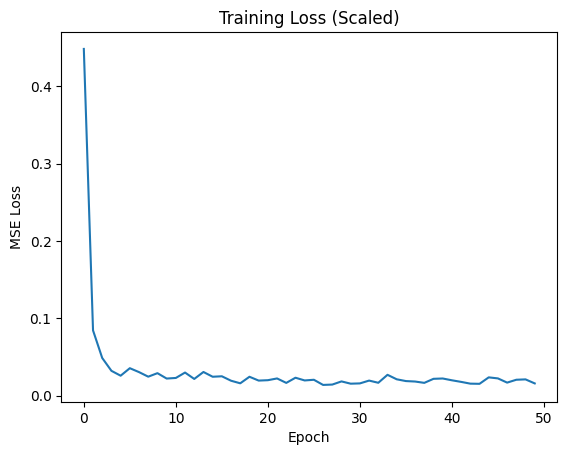

In [7]:
criterion = nn.MSELoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

epochs = 50
train_losses = []

print("Starting training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for batch in train_loader:
        imgs = batch['image'].to(device)
        tabs = batch['tabular'].to(device)
        targets = batch['target'].to(device)

        optimizer.zero_grad()
        outputs = model(imgs, tabs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.6f}")

print("Training completed.")

plt.plot(train_losses)
plt.title("Training Loss (Scaled)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler

R² Score: 0.7527


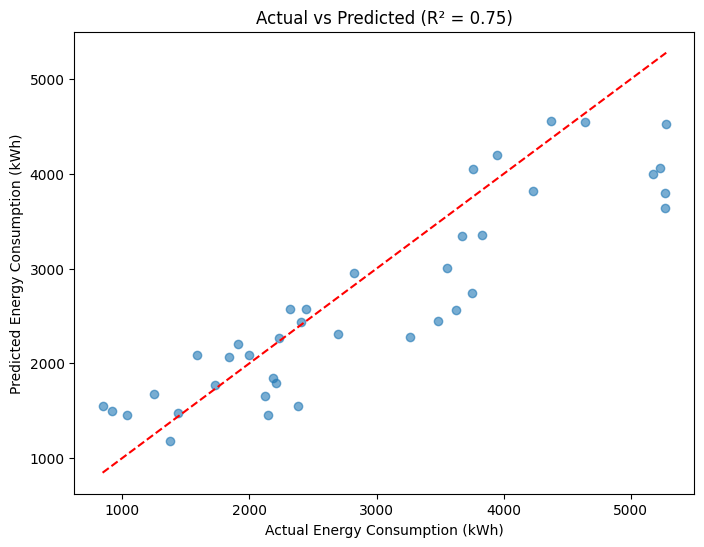

In [8]:
model.eval()
pred_scaled = []
true_scaled = []

with torch.no_grad():
    for batch in test_loader:
        imgs = batch['image'].to(device)
        tabs = batch['tabular'].to(device)
        targets = batch['target'].to(device)

        outputs = model(imgs, tabs)

        pred_scaled.extend(outputs.cpu().numpy())
        true_scaled.extend(targets.cpu().numpy())

# Inverse Transform
predictions = target_scaler.inverse_transform(np.array(pred_scaled).reshape(-1, 1))
actuals = target_scaler.inverse_transform(np.array(true_scaled).reshape(-1, 1))

# Metrics
r2 = r2_score(actuals, predictions)
print(f"R² Score: {r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(actuals, predictions, alpha=0.6)
plt.plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], 'r--')
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Predicted Energy Consumption (kWh)")
plt.title(f"Actual vs Predicted (R² = {r2:.2f})")
plt.show()

In [9]:
# Save the final model weights
save_path = "../models/sustainability_model.pth"
os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), save_path)
print(f"Model saved successfully to {save_path}")

Model saved successfully to ../models/sustainability_model.pth
